In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

pd.set_option('display.max_columns', None)


In [3]:
df = pd.read_csv("C:\\Users\\rohin\\Sucide Project\\Feature Engineering\\final_model_dataset_FEATURES.csv")

df.head()

,Year,AlcoholConsumption,HomicideRate,GDP_per_capita,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",SuicideRate,AlcoholConsumption_lag1,HomicideRate_lag1,GDP_per_capita_lag1,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x_lag1",AlcoholConsumption_lag2,HomicideRate_lag2,GDP_per_capita_lag2,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x_lag2",AlcoholConsumption_roll3,HomicideRate_roll3,GDP_per_capita_roll3,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x_roll3",Year_scaled
0,2000,8.742056,45.012212,3217.846934,22.714,13.132524,8.742056,45.012212,3217.846934,22.714,8.742056,45.012212,3217.846934,22.714,8.655983,45.858397,2917.745205,22.622000,0
1,2001,8.742056,45.090413,2847.151919,22.605,13.245669,8.742056,45.012212,3217.846934,22.714,8.742056,45.012212,3217.846934,22.714,8.655983,45.858397,2917.745205,22.622000,1
2,2002,8.483838,47.472567,2688.236760,22.547,14.598869,8.742056,45.090413,2847.151919,22.605,8.742056,45.012212,3217.846934,22.714,8.655983,45.858397,2917.745205,22.622000,2
3,2003,8.366666,44.799503,4062.217560,22.629,15.759870,8.483838,47.472567,2688.236760,22.547,8.742056,45.090413,2847.151919,22.605,8.530853,45.787494,3199.202080,22.593667,3
4,2004,8.343871,44.530240,5221.463337,22.538,16.074981,8.366666,44.799503,4062.217560,22.629,8.483838,47.472567,2688.236760,22.547,8.398125,45.600770,3990.639219,22.571333,4


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 19 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   Year                                                                         25 non-null     int64  
 1   AlcoholConsumption                                                           25 non-null     float64
 2   HomicideRate                                                                 25 non-null     float64
 3   GDP_per_capita                                                               25 non-null     float64
 4   Unemployment, total (% of total labor force) (modeled ILO estimate)_x        25 non-null     float64
 5   SuicideRate                                                                  25 non-null     float64
 6   AlcoholConsumption_lag1                     

,Year,AlcoholConsumption,HomicideRate,GDP_per_capita,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",SuicideRate,AlcoholConsumption_lag1,HomicideRate_lag1,GDP_per_capita_lag1,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x_lag1",AlcoholConsumption_lag2,HomicideRate_lag2,GDP_per_capita_lag2,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x_lag2",AlcoholConsumption_roll3,HomicideRate_roll3,GDP_per_capita_roll3,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x_roll3",Year_scaled
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,2012.000000,8.289990,20.523564,6072.452899,25.815480,18.194975,8.327997,21.822722,5940.230337,25.397320,8.366005,23.121881,5808.007775,25.021960,8.321112,21.889374,5921.164799,25.405680,12.000000
std,7.359801,0.288134,12.800318,1506.921621,3.813187,2.800270,0.282299,13.580023,1607.376854,3.536463,0.270842,14.194000,1691.178707,3.284664,0.256742,13.224231,1558.809641,3.479509,7.359801
min,2000.000000,7.791870,12.533244,2688.236760,22.287000,13.132524,7.791870,12.533244,2688.236760,22.287000,7.791870,12.533244,2688.236760,22.287000,7.791870,12.533244,2917.745205,22.339333,0.000000
25%,2006.000000,8.239292,13.446773,5651.205852,22.605000,16.074981,8.248683,13.508287,5580.603831,22.605000,8.336959,13.510317,5221.463337,22.605000,8.274978,13.524487,5711.907635,22.622000,6.000000
50%,2012.000000,8.397732,13.955669,6523.410978,24.683000,18.186891,8.402676,14.266698,6374.705600,24.639000,8.421343,14.477758,6184.754743,24.561000,8.399800,14.045817,6319.238153,24.642333,12.000000
75%,2018.000000,8.451479,17.915438,6843.399419,27.035000,20.140313,8.451979,18.905256,6843.399419,26.906000,8.470212,44.530240,6843.399419,26.536000,8.445688,27.116978,6688.741442,26.825667,18.000000
max,2024.000000,8.742056,47.472567,8646.055711,34.007000,22.295801,8.742056,47.472567,8646.055711,34.007000,8.742056,47.472567,8646.055711,34.007000,8.655983,45.858397,8232.168151,33.124333,24.000000


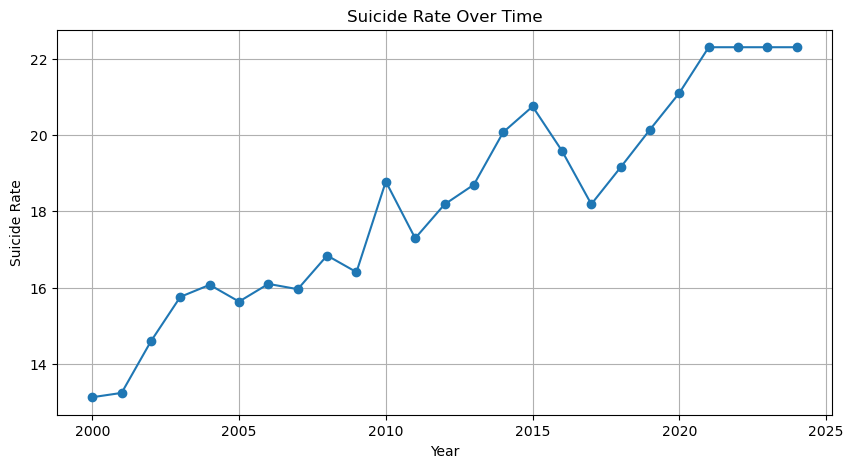

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df['Year'], df['SuicideRate'], marker='o')
plt.title("Suicide Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Suicide Rate")
plt.grid(True)
plt.show()

In [6]:
df['SuicideRate_diff'] = df['SuicideRate'].diff()

df[['Year', 'SuicideRate', 'SuicideRate_diff']].head(10)

,Year,SuicideRate,SuicideRate_diff
0,2000,13.132524,NaN
1,2001,13.245669,0.113145
2,2002,14.598869,1.353199
3,2003,15.759870,1.161001
4,2004,16.074981,0.315110
5,2005,15.636315,-0.438666
6,2006,16.099597,0.463282
7,2007,15.960853,-0.138744
8,2008,16.842257,0.881404
9,2009,16.407856,-0.434401


In [7]:
df = df.dropna().reset_index(drop=True)

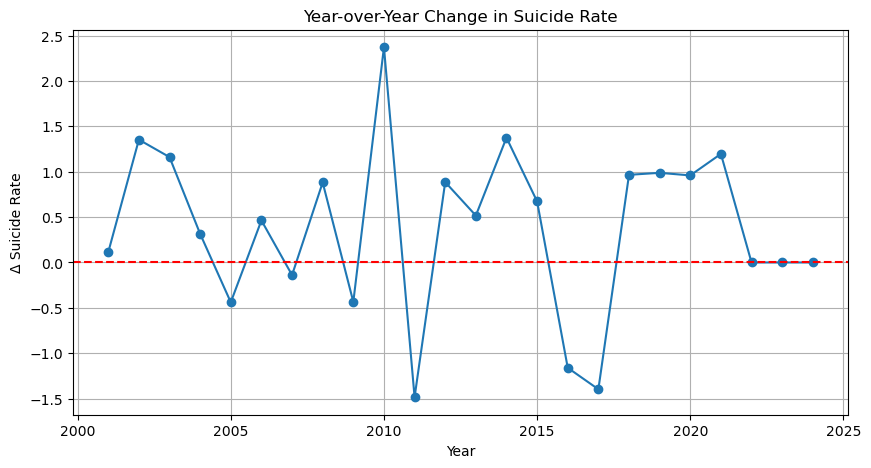

In [8]:
plt.figure(figsize=(10,5))
plt.plot(df['Year'], df['SuicideRate_diff'], marker='o')
plt.axhline(0, color='red', linestyle='--')
plt.title("Year-over-Year Change in Suicide Rate")
plt.xlabel("Year")
plt.ylabel("Δ Suicide Rate")
plt.grid(True)
plt.show()

In [9]:
selected_features = [
    'AlcoholConsumption_roll3',
    'HomicideRate_roll3',
    'GDP_per_capita_roll3',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)_x_roll3'
]

X = df[selected_features]
y = df['SuicideRate_diff']


In [10]:
X.head()

,AlcoholConsumption_roll3,HomicideRate_roll3,GDP_per_capita_roll3,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x_roll3"
0,8.655983,45.858397,2917.745205,22.622000
1,8.655983,45.858397,2917.745205,22.622000
2,8.530853,45.787494,3199.202080,22.593667
3,8.398125,45.600770,3990.639219,22.571333
4,8.371071,36.078333,5040.185844,22.542667


In [11]:
corr = pd.concat([X, y], axis=1).corr()

corr['SuicideRate_diff'].sort_values(ascending=False)


SuicideRate_diff                                                               1.000000
HomicideRate_roll3                                                             0.102268
AlcoholConsumption_roll3                                                       0.052525
Unemployment, total (% of total labor force) (modeled ILO estimate)_x_roll3   -0.062324
GDP_per_capita_roll3                                                          -0.067353
Name: SuicideRate_diff, dtype: float64

In [12]:
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


In [13]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

preds = ridge.predict(X_test)

mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R²:  {r2:.4f}")

MAE: 0.4751
MSE: 0.3872
R²:  -0.3614


In [14]:
directional_accuracy = np.mean(
    np.sign(y_test.values) == np.sign(preds)
)

print(f"Directional Accuracy: {directional_accuracy:.2%}")


Directional Accuracy: 40.00%


In [15]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100]}

ridge_search = GridSearchCV(
    Ridge(),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

ridge_search.fit(X_train, y_train)

ridge_search.best_params_


{'alpha': 100}

In [16]:
best_ridge = ridge_search.best_estimator_

final_preds = best_ridge.predict(X_test)

print("Final MAE:", mean_absolute_error(y_test, final_preds))
print("Final Directional Accuracy:",
      np.mean(np.sign(y_test.values) == np.sign(final_preds)))


Final MAE: 0.47194555259731474
Final Directional Accuracy: 0.4


In [17]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_ridge.coef_
}).sort_values(by='Coefficient', ascending=False)

coef_df


,Feature,Coefficient
1,HomicideRate_roll3,0.025971
0,AlcoholConsumption_roll3,0.001579
3,"Unemployment, total (% of total labor force) (...",0.000358
2,GDP_per_capita_roll3,0.000155


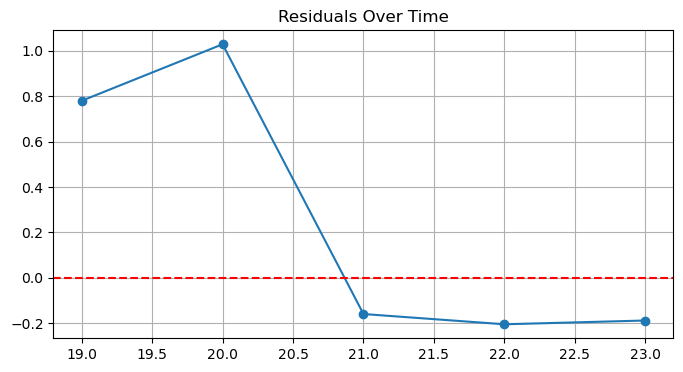

In [18]:
residuals = y_test - final_preds

plt.figure(figsize=(8,4))
plt.plot(residuals, marker='o')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals Over Time")
plt.grid(True)
plt.show()


In [19]:
final_preds

array([0.17977082, 0.16785649, 0.15937986, 0.20453482, 0.18795291])